In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("wine.csv")
print(df.shape)
print(df.info())
df.head()

(178, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB
None


,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


# 1. EDA

In [3]:
# Null and duplicate check
print(df.isnull().sum())
print(df.duplicated().sum())

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64
0


In [4]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


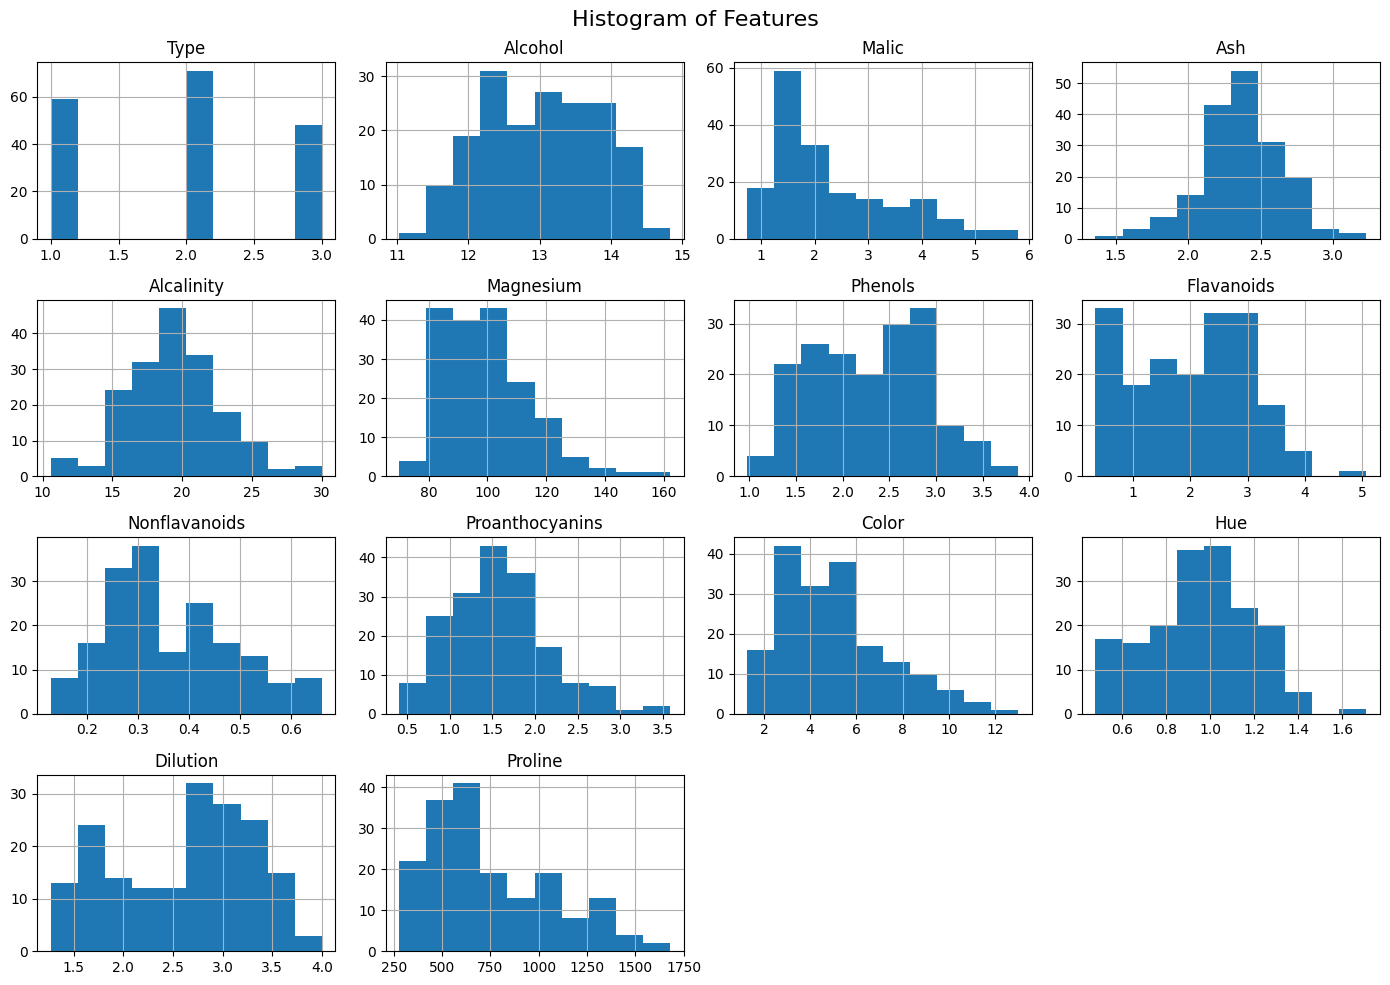

In [5]:
# Histogram of all features
df.hist(figsize=(14, 10))
plt.suptitle('Histogram of Features', fontsize=16)
plt.tight_layout()
plt.show()

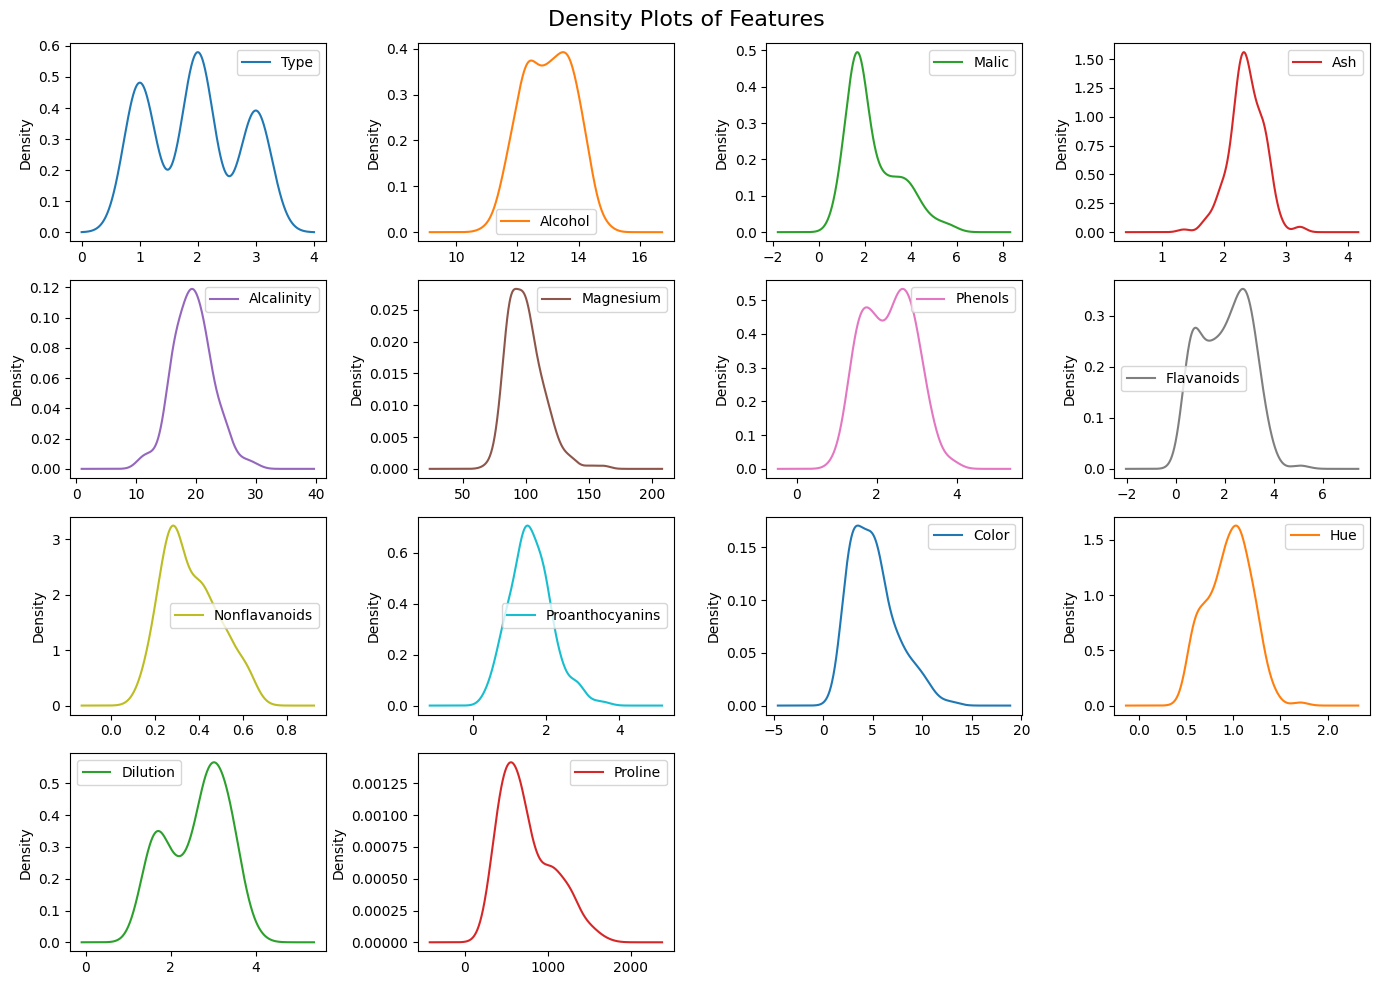

In [6]:
# Density plots of all features
df.plot(kind='density', subplots=True, layout=(4, 4), sharex=False, figsize=(14, 10))
plt.suptitle('Density Plots of Features', fontsize=16)
plt.tight_layout()
plt.show()

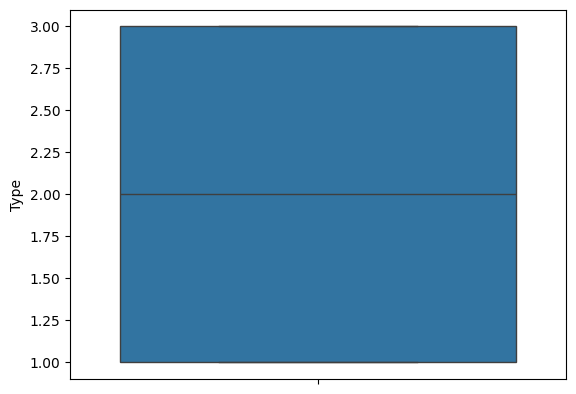

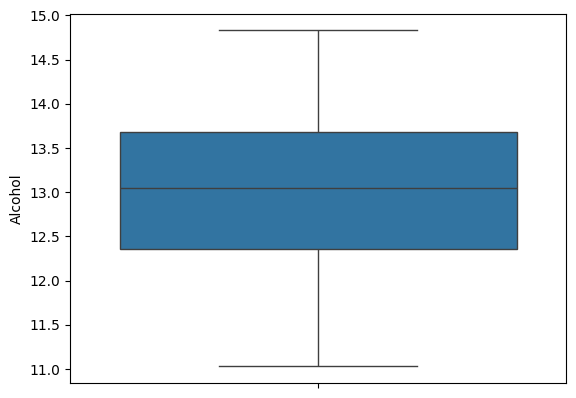

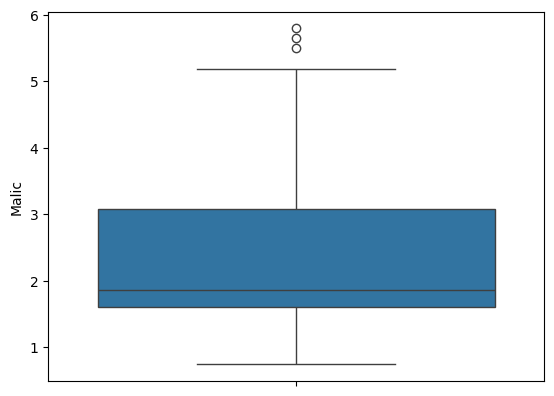

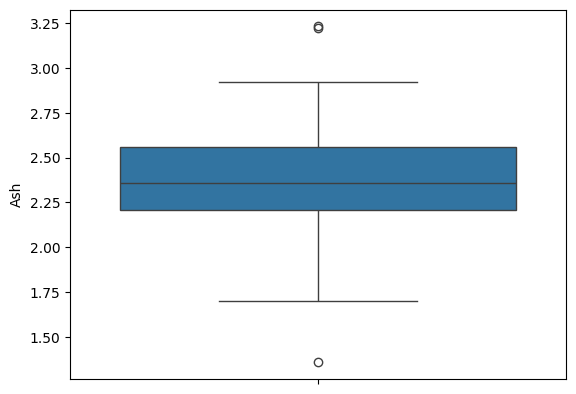

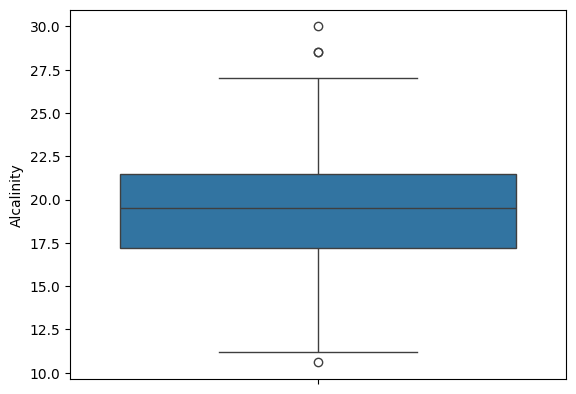

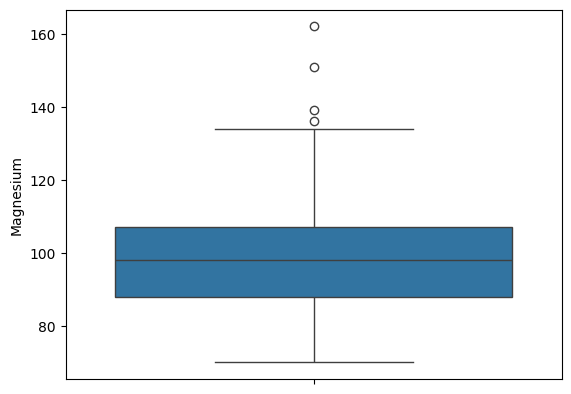

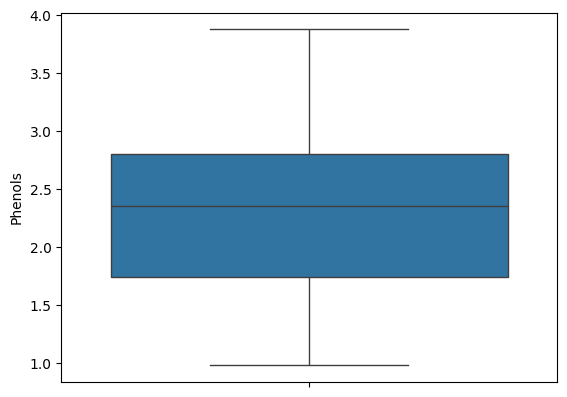

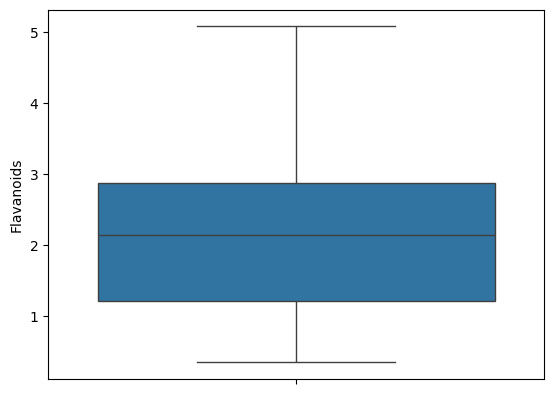

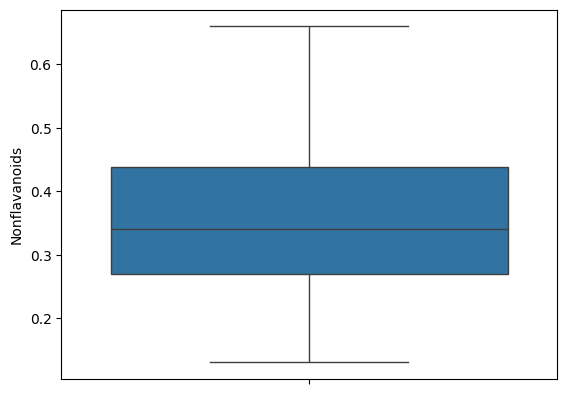

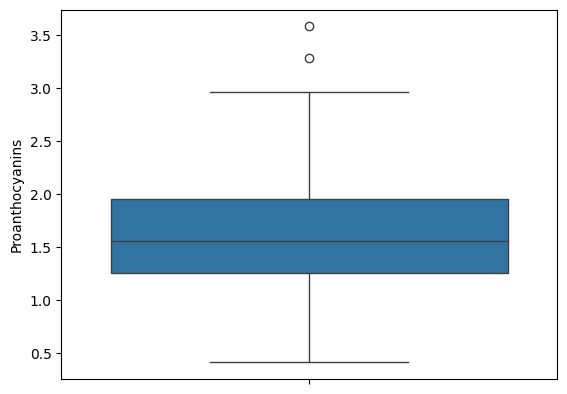

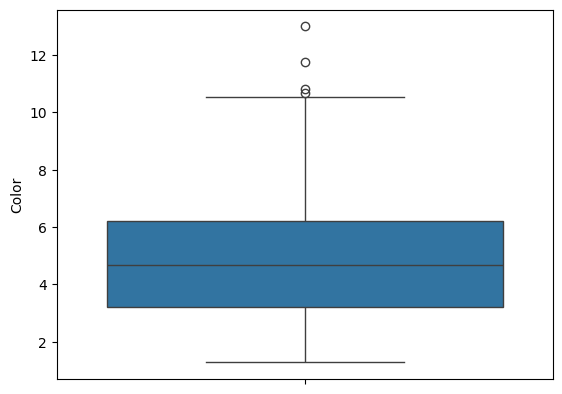

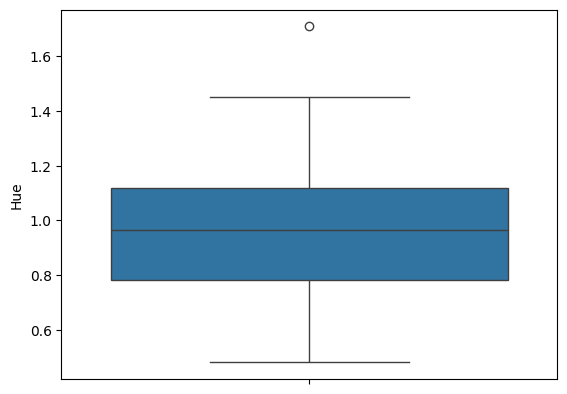

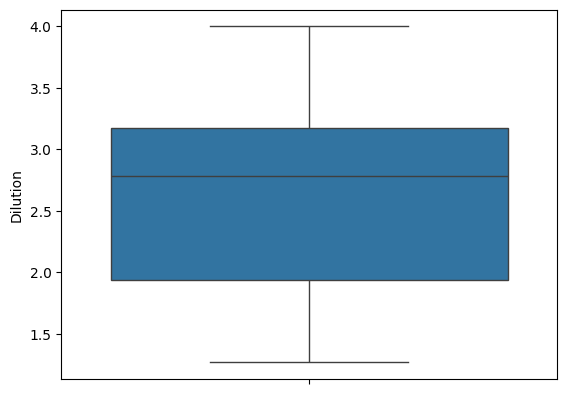

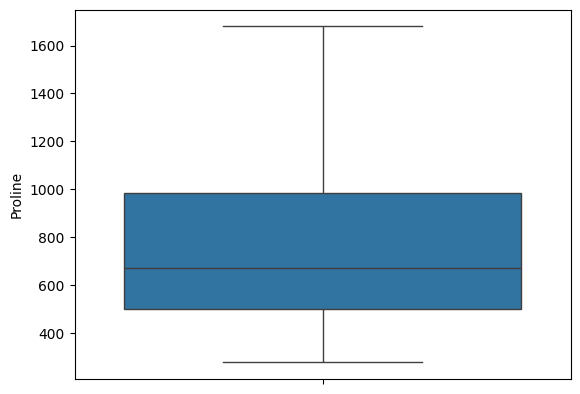

In [7]:
# Outlier boxplots
for col in df.select_dtypes(["int", "float"]).columns:
    sns.boxplot(data=df, y=col)
    plt.show()

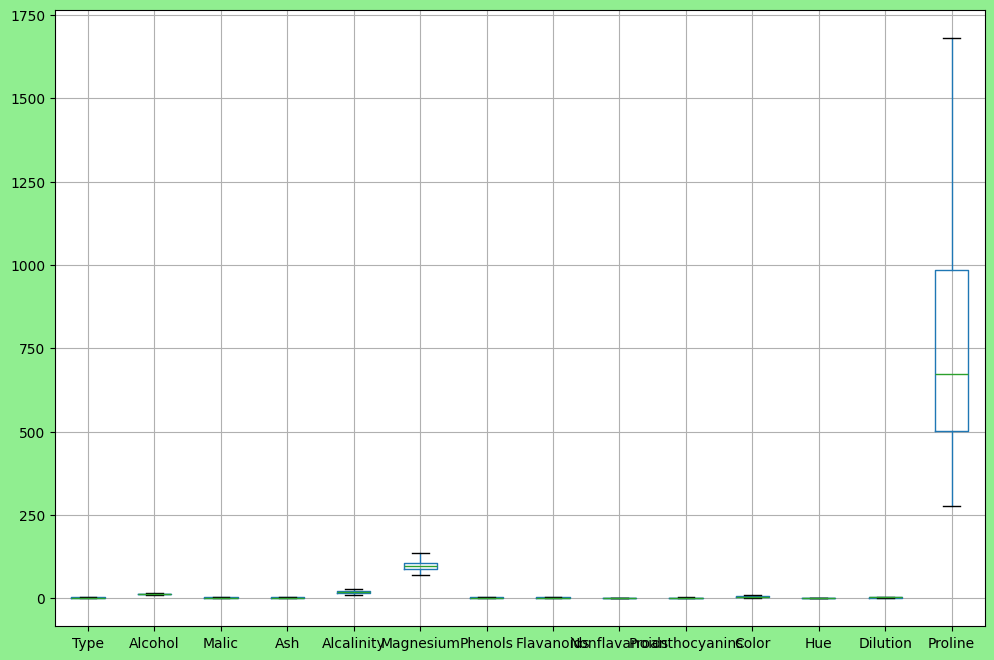

In [8]:
# Replace outliers
def replace_outliers(df):
    def replace(col):
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_extreme = Q1 - 1.5 * IQR
        upper_extreme = Q3 + 1.5 * IQR
        df[col] = df[col].apply(
            lambda x: lower_extreme if x < lower_extreme
            else upper_extreme if x > upper_extreme
            else x
        )
    for c in df.select_dtypes(include=["int", "float"]).columns:
        replace(c)

plt.figure(figsize=(12, 8), facecolor="lightgreen")
replace_outliers(df)
df.boxplot()
plt.show()

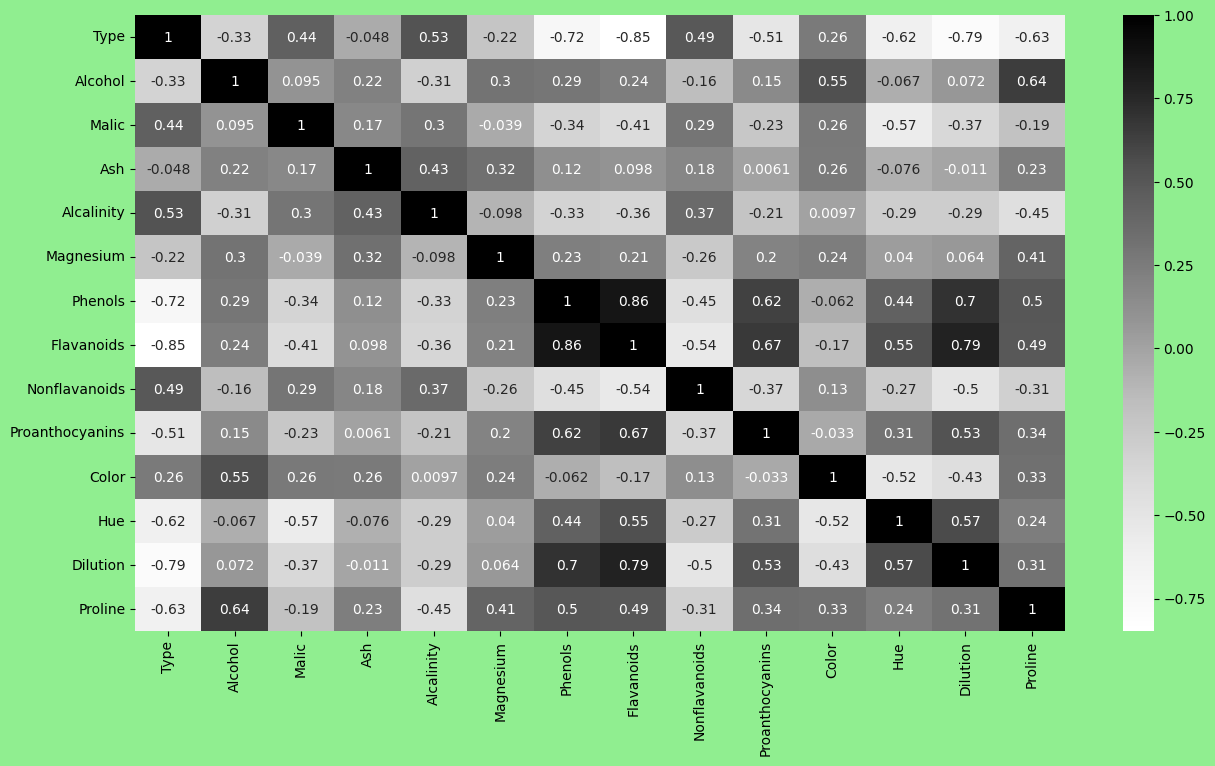

In [9]:
# Correlation heatmap
corrs = df.corr()
plt.figure(figsize=(15, 8), facecolor="lightgreen")
sns.heatmap(corrs, annot=True, cmap=plt.cm.Greys)
plt.show()

In [10]:
# Data Splitting
features = df.drop(columns=["Type"])
target = df["Type"]

x_train, x_test, y_train, y_test = train_test_split(
    features, target, train_size=0.8, random_state=100, stratify=df["Type"]
)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(142, 13)
(142,)
(36, 13)
(36,)


In [11]:
# Scaling
std_sca = StandardScaler()
cols = df.select_dtypes(["float"]).columns

x_train[cols] = std_sca.fit_transform(x_train[cols])
x_test[cols]  = std_sca.transform(x_test[cols])
x_train.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
94,-1.657794,-0.324786,-0.308917,-0.409492,-0.142468,1.164956,0.230224,-1.547934,-0.423718,-0.800591,0.908924,0.501132,345
63,-0.723591,-1.101006,-0.782400,-0.096364,-0.971275,1.922477,1.069499,-1.387900,0.531620,-0.246846,1.177183,0.374911,420
61,-0.387278,-0.893412,-1.334797,-0.785245,0.008224,-0.413214,-0.619043,1.332677,-1.764865,0.353045,0.104147,-1.420236,450
156,1.107447,1.597712,0.085652,0.060200,-0.820583,-0.760411,-1.198542,0.932592,-0.037908,1.857388,-1.728956,-1.350113,480
28,1.144815,-0.406019,1.742843,0.028887,0.535647,1.054484,0.939611,0.052405,0.329529,-0.223773,1.311312,1.118214,915


# 2. Dimensionality Reduction with PCA

In [12]:
pca = PCA(n_components=10)
x_train_pca = pca.fit_transform(x_train)
x_test_pca  = pca.transform(x_test)
print(x_train_pca.shape)
print(x_test_pca.shape)

(142, 10)
(36, 10)


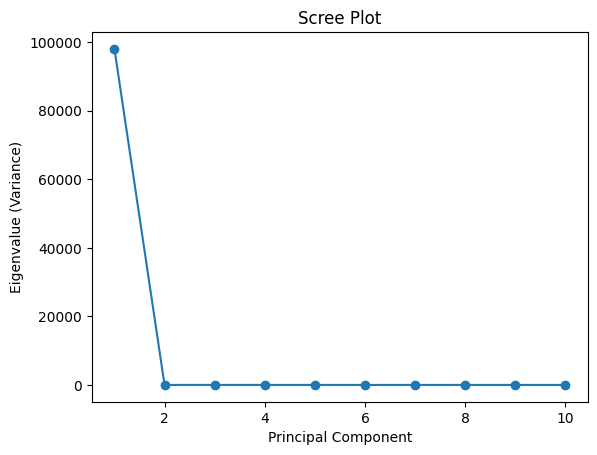

In [13]:
# Scree Plot
plt.plot(range(1, len(pca.explained_variance_) + 1),
         pca.explained_variance_, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue (Variance)')
plt.title('Scree Plot')
plt.show()

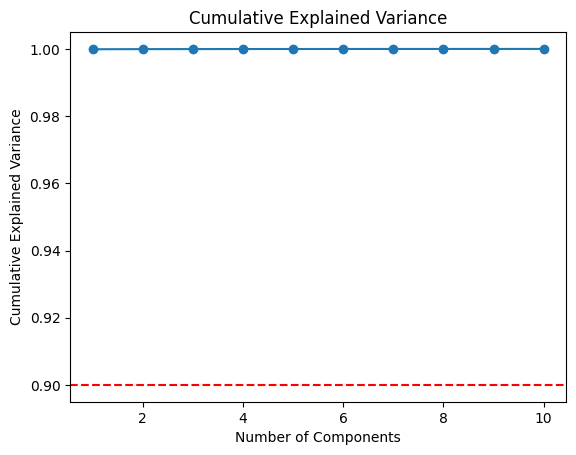

In [14]:
# Cumulative Explained Variance
cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.axhline(y=0.90, color='r', linestyle='--')
plt.show()

# 3. Clustering

In [15]:
# Clustering on original dataset
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit(features)
print(len(clusters.labels_), np.unique(clusters.labels_))

178 [0 1 2]


In [16]:
features["cluster"] = clusters.labels_
features.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,cluster
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [17]:
print(features[features.cluster == 0].shape)
print(features[features.cluster == 1].shape)
print(features[features.cluster == 2].shape)

(104, 14)
(47, 14)
(27, 14)


In [18]:
print("Silhouette Score (original):", silhouette_score(features, clusters.labels_))
print("Inertia (original):", kmeans.inertia_)

Silhouette Score (original): 0.563188674888302
Inertia (original): 2633920.7788469107


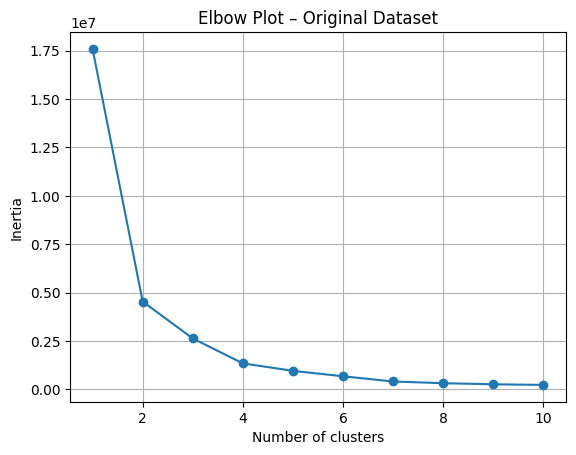

In [19]:
# Elbow plot – original dataset
inertia_values = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(features)
    inertia_values.append(km.inertia_)

plt.plot(range(1, 11), inertia_values, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Plot – Original Dataset')
plt.grid()
plt.show()

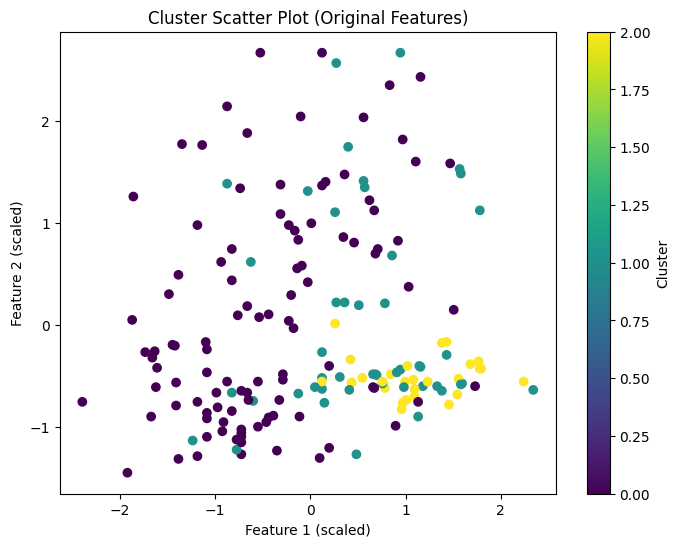

In [20]:
# Clustering scatter plot – original scaled features
float_cols = df.select_dtypes(['float']).columns
X_scaled = std_sca.transform(features[float_cols])

plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_, cmap='viridis')
plt.title('Cluster Scatter Plot (Original Features)')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.colorbar(label='Cluster')
plt.show()

In [21]:
# Best PCA + KMeans combo via silhouette score
best_score = float("-inf")
pca_val = 0
clusters_val = 0

for i in range(1, 11):
    for j in range(2, 11):
        pca_check = PCA(n_components=i)
        trained = pca_check.fit_transform(x_train)
        km_check = KMeans(n_clusters=j, random_state=42)
        km_check.fit(trained)
        score = silhouette_score(trained, km_check.labels_)
        if score >= best_score:
            pca_val = i
            clusters_val = j
            best_score = score

print("Best silhouette score:", best_score)
print("Best PCA components  :", pca_val)
print("Best clusters        :", clusters_val)

Best silhouette score: 0.6435348264097814
Best PCA components  : 1
Best clusters        : 2


In [22]:
# Clustering with PCA-transformed dataset
pca2 = PCA(n_components=3)
x_train_pca2 = pca2.fit_transform(x_train)
print(x_train_pca2.shape)

(142, 3)


In [23]:
kmeans2 = KMeans(n_clusters=2, random_state=42)
clusters2 = kmeans2.fit(x_train_pca2)
print(len(clusters2.labels_), np.unique(clusters2.labels_))

142 [0 1]


In [24]:
print("Silhouette Score (PCA):", silhouette_score(x_train_pca2, clusters2.labels_))

Silhouette Score (PCA): 0.643336384216073


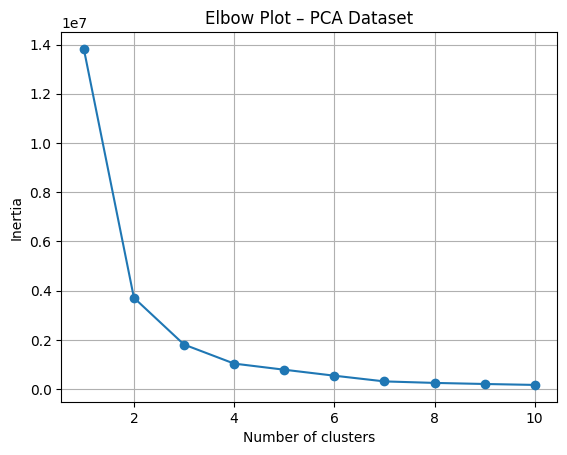

In [25]:
# Elbow plot – PCA dataset
inertia_values2 = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(x_train_pca2)
    inertia_values2.append(km.inertia_)

plt.plot(range(1, 11), inertia_values2, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Plot – PCA Dataset')
plt.grid()
plt.show()

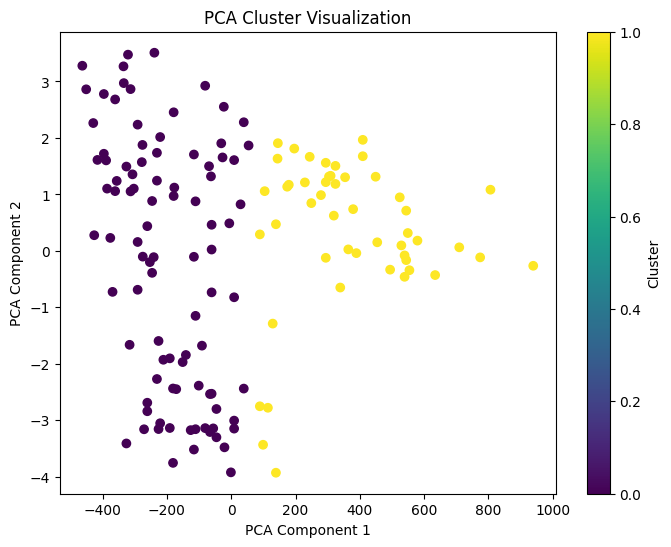

In [26]:
# PCA cluster visualization
X_pca = x_train_pca2   # 3 PCA components; plot first 2
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans2.labels_, cmap='viridis')
plt.title('PCA Cluster Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

In [27]:
# Comparison – silhouette scores
print("Silhouette Score – original dataset :", silhouette_score(features, clusters.labels_))
print("Silhouette Score – PCA dataset      :", silhouette_score(x_train_pca2, clusters2.labels_))

Silhouette Score – original dataset : 0.563188674888302
Silhouette Score – PCA dataset      : 0.643336384216073


In [28]:
'''
1) The clustering results after PCA show improved cluster separation, as reflected by a higher
   silhouette score compared to the original dataset. PCA reduces dimensionality while retaining
   the most informative variance, which helps distance-based algorithms like KMeans perform better.

2) Dimensionality reduction with PCA reduces the number of features, adding the essence of the
   eliminated features to the retained ones. This controls overfitting by reducing multicollinearity.

3) Clustering on the original dataset preserves complete feature information and interpretability
   but may suffer from noise and unreliable distances in higher dimensions. PCA improves clustering
   quality at the cost of explainability.
'''

'\n1) The clustering results after PCA show improved cluster separation, as reflected by a higher\n   silhouette score compared to the original dataset. PCA reduces dimensionality while retaining\n   the most informative variance, which helps distance-based algorithms like KMeans perform better.\n\n2) Dimensionality reduction with PCA reduces the number of features, adding the essence of the\n   eliminated features to the retained ones. This controls overfitting by reducing multicollinearity.\n\n3) Clustering on the original dataset preserves complete feature information and interpretability\n   but may suffer from noise and unreliable distances in higher dimensions. PCA improves clustering\n   quality at the cost of explainability.\n'

### Key Findings

- The dataset consisted of multiple continuous, correlated features, making it suitable for PCA after proper standardisation.
- PCA revealed that 2–3 principal components were sufficient to capture ≈ 80–90% of total variance.
- Clustering after PCA showed better cluster compactness, reflected by an improved silhouette score.
- PCA reduced noise and multicollinearity, improving KMeans performance.
- Clustering on the original data preserves feature-level interpretability; PCA-based clustering trades interpretability for better efficiency.

**Recommendation:** Use PCA + clustering when features are correlated/noisy and scalability matters. Use original features when interpretability is a priority.